# Red Neuronal para Predicción de Impago de Tarjetas de Crédito

Este notebook contiene el código paso a paso para construir, entrenar y evaluar una red neuronal utilizando el dataset `default of credit card clients.csv`. Está diseñado con celdas de Markdown (texto) que explican cada paso del proceso, siguiendo un enfoque metodológico de Ciencia de Datos.

## 1. Importación de Librerías

Para este proyecto utilizaremos:
* **Pandas y Numpy:** Para la manipulación y análisis de datos.
* **Scikit-Learn (sklearn):** Para dividir los datos, escalarlos y evaluar el modelo (matriz de confusión).
* **TensorFlow / Keras:** Para construir la arquitectura de la red neuronal profunda.
* **Matplotlib y Seaborn:** Para visualizar los resultados (mapas de calor).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from pathlib import Path
from sysconfig import get_paths
import ctypes
import os

site_packages = Path(get_paths()['purelib'])
cuda_lib_dirs = [
    site_packages / 'nvidia' / 'cuda_runtime' / 'lib',
    site_packages / 'nvidia' / 'cuda_nvrtc' / 'lib',
    site_packages / 'nvidia' / 'cublas' / 'lib',
    site_packages / 'nvidia' / 'cufft' / 'lib',
    site_packages / 'nvidia' / 'curand' / 'lib',
    site_packages / 'nvidia' / 'cusolver' / 'lib',
    site_packages / 'nvidia' / 'cusparse' / 'lib',
    site_packages / 'nvidia' / 'cudnn' / 'lib',
    site_packages / 'nvidia' / 'cuda_cupti' / 'lib',
    site_packages / 'nvidia' / 'nccl' / 'lib',
    site_packages / 'nvidia' / 'nvjitlink' / 'lib',
]

loaded_cuda_libs = 0
for lib_dir in cuda_lib_dirs:
    if lib_dir.exists():
        for lib_path in sorted(lib_dir.glob('*.so*')):
            ctypes.CDLL(str(lib_path), mode=ctypes.RTLD_GLOBAL)
            loaded_cuda_libs += 1

existing_ld = os.environ.get('LD_LIBRARY_PATH', '')
cuda_ld_paths = [str(path) for path in cuda_lib_dirs if path.exists()]
if existing_ld:
    cuda_ld_paths.append(existing_ld)
os.environ['LD_LIBRARY_PATH'] = ':'.join(cuda_ld_paths)
print(f'Librerías CUDA cargadas: {loaded_cuda_libs}')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print('TensorFlow:', tf.__version__)
print('GPUs detectadas:', gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Crecimiento de memoria habilitado.")
    except RuntimeError as e:
        print(e)

# Ignorar advertencias para una salida más limpia
import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1783725830.239996  229620 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Librerías CUDA cargadas: 31
TensorFlow: 2.21.0
GPUs detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Crecimiento de memoria habilitado.


## 2. Carga y Exploración de Datos

Cargamos el archivo CSV. Basándonos en la estructura del archivo, este utiliza un punto y coma (`;`) como separador y tiene un doble encabezado (las variables X1, X2 y luego los nombres descriptivos). Nos quedaremos con los nombres descriptivos. Además, eliminamos la columna `ID` ya que es un identificador único que no tiene poder predictivo y podría confundir a la red neuronal.

In [ ]:
df = pd.read_csv('../Dataset/default of credit card clients.csv', sep=',', skiprows=1)

# Renombrar la variable objetivo a algo más sencillo
if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'default'}, inplace=True)

# Eliminar la columna ID
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

# Mostrar las primeras 5 filas
display(df.head())

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. Preprocesamiento de Datos (Crítico)

Las redes neuronales son extremadamente sensibles a la escala de los datos. Si tenemos una columna con valores en los cientos de miles (como el límite de crédito `LIMIT_BAL`) y otra con valores pequeños (como el estado de pago `PAY_0` que va de -2 a 8), los gradientes durante el entrenamiento pueden volverse inestables.

* **Separación X e y:** Dividimos en variables predictoras (`X`) y variable objetivo (`y`).
* **División Train/Test:** 80% de los datos para entrenar la red, 20% para probar que no se haya memorizado los datos (overfitting).
* **Escalado:** Usamos `StandardScaler` para que todas las variables tengan media 0 y desviación estándar 1.

In [3]:
# 1. Separar variables predictoras (X) y objetivo (y)
X = df.drop('default', axis=1)
y = df['default']

# 2. Dividir en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamaño del set de entrenamiento: {X_train_scaled.shape}")
print(f"Tamaño del set de prueba: {X_test_scaled.shape}")

Tamaño del set de entrenamiento: (24000, 23)
Tamaño del set de prueba: (6000, 23)


## 4. Construcción de la Red Neuronal

Definimos una arquitectura *Feedforward* (Secuencial).
* **Capa de entrada:** Automáticamente inferida por la primera capa oculta (espera 23 características).
* **Capas ocultas:** Dos capas densas (`Dense`) con activación `ReLU` para capturar patrones no lineales complejos.
* **Capa de salida:** Una sola neurona con activación `sigmoid`. Esta función comprime el resultado entre 0 y 1, dándonos una "probabilidad" de que el cliente incumpla (1).

In [4]:
# Inicializar el modelo secuencial
model = Sequential()

# Primera capa oculta (y capa de entrada implícita)
model.add(Dense(units=32, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(BatchNormalization()) # Normaliza las activaciones para estabilizar el entrenamiento
model.add(Activation('relu'))   # Activación separada
model.add(Dropout(0.2)) # Apaga el 20% de las neuronas al azar para evitar sobreajuste

# Segunda capa oculta
model.add(Dense(units=16))
model.add(BatchNormalization())
model.add(Activation('relu'))   
model.add(Dropout(0.2))

# Capa de salida
# Una neurona, activación sigmoide para clasificación binaria (0 o 1)
model.add(Dense(units=1, activation='sigmoid'))

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Mostrar el resumen de la arquitectura
model.summary()

I0000 00:00:1783725850.145392  229620 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1966 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,505 (5.88 KB)

 Trainable params: 1,409 (5.50 KB)

 Non-trainable params: 96 (384.00 B)

In [5]:
# EarlyStopping: Detiene el entrenamiento si el modelo no mejora
early_stopping = EarlyStopping(
    monitor='val_loss',       # Qué métrica vigilar (pérdida en validación)
    patience=7,               # Cuántas épocas esperar sin mejora antes de parar
    restore_best_weights=True,# Restaurar los mejores pesos encontrados
    verbose=1
)

# ReduceLROnPlateau: Reduce la tasa de aprendizaje si el modelo se estanca
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               # Cuánto reducir el learning rate (a la mitad)
    patience=3,               # Cuántas épocas esperar antes de reducirlo
    min_lr=1e-5,              # Límite mínimo para no quedar en cero
    verbose=1
)

# Agrupamos los callbacks
callbacks_list = [early_stopping, reduce_lr]

## 5. Entrenamiento del Modelo

Entrenamos la red pasando los datos varias veces (`epochs`). En cada época (iteración), el modelo ajusta sus "pesos" internos para reducir el error (`loss`). Usamos un `batch_size` de 32, lo que significa que actualiza los pesos cada 32 ejemplos.

In [6]:
# Calcular pesos
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {0: weights[0], 1: weights[1]}

# Entrenar la red neuronal
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=200,          # Número de veces que verá todos los datos
    batch_size=32,      # Muestras por actualización de gradiente
    validation_split=0.2, # Usar 20% del set de train para validación interna
    verbose=1,
    class_weight=class_weights,
    callbacks=callbacks_list
)

Epoch 1/200


I0000 00:00:1783725861.477179  230121 service.cc:153] XLA service 0x7f834c036d40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783725861.477201  230121 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2050, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783725861.504792  230121 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783725861.760467  230121 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783725861.815615  230121 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2263__.18


107/600 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4632 - loss: 0.7288

I0000 00:00:1783725863.965980  230121 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6339 - loss: 0.6496 - val_accuracy: 0.7348 - val_loss: 0.6183 - learning_rate: 0.0010
Epoch 2/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7164 - loss: 0.6064 - val_accuracy: 0.7644 - val_loss: 0.5802 - learning_rate: 0.0010
Epoch 3/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7402 - loss: 0.5906 - val_accuracy: 0.7742 - val_loss: 0.5654 - learning_rate: 0.0010
Epoch 4/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7394 - loss: 0.5857 - val_accuracy: 0.7706 - val_loss: 0.5570 - learning_rate: 0.0010
Epoch 5/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7480 - loss: 0.5810 - val_accuracy: 0.7758 - val_loss: 0.5569 - learning_rate: 0.0010
Epoch 6/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7429 - loss: 0.5775 - val_accuracy: 0.7746 - val_loss: 0.5541 - learning_rate: 0.0010
Epoch 7/200
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7508 - loss: 0.5763 - val_a

## 6. Evaluación y Visualización (Resultados)

Como sugerimos para tu exposición, la métrica global de precisión (`accuracy`) no es suficiente en problemas financieros. Generamos las predicciones y visualizamos la **Matriz de Confusión** utilizando un mapa de calor (`heatmap`). Esto permite ver:
* **Verdaderos Positivos / Negativos:** Aciertos del modelo.
* **Falsos Negativos:** Clientes que iban a incumplir, pero el modelo confió en ellos (el error más costoso para el banco).
* **Falsos Positivos:** Clientes cumplidos a los que el modelo marcó como riesgo.

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


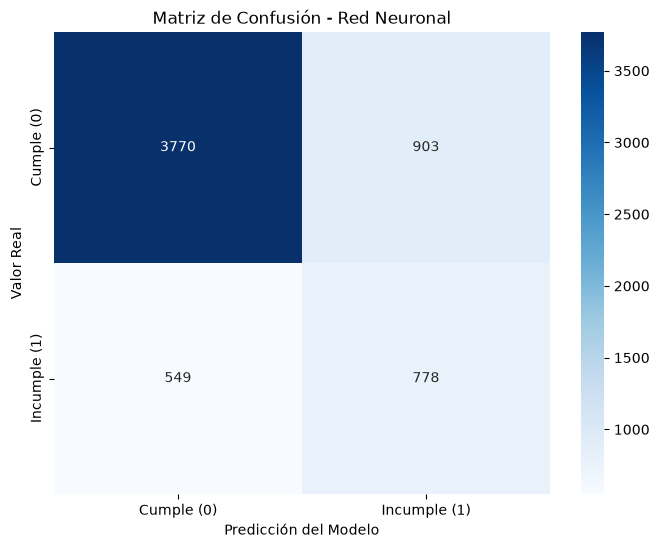


Reporte de Clasificación:
              precision    recall  f1-score   support

  Cumple (0)       0.87      0.81      0.84      4673
Incumple (1)       0.46      0.59      0.52      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.76      0.77      6000



In [7]:
# Obtener predicciones (probabilidades)
y_pred_prob = model.predict(X_test_scaled)

# Convertir probabilidades a clases binarias (0 o 1) usando un umbral de 0.5
y_pred = (y_pred_prob > 0.5).astype(int)

# --- MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cumple (0)', 'Incumple (1)'], 
            yticklabels=['Cumple (0)', 'Incumple (1)'])
plt.title('Matriz de Confusión - Red Neuronal')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# --- REPORTE DE CLASIFICACIÓN ---
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Cumple (0)', 'Incumple (1)']))

## Curva ROC y ROC-AUC

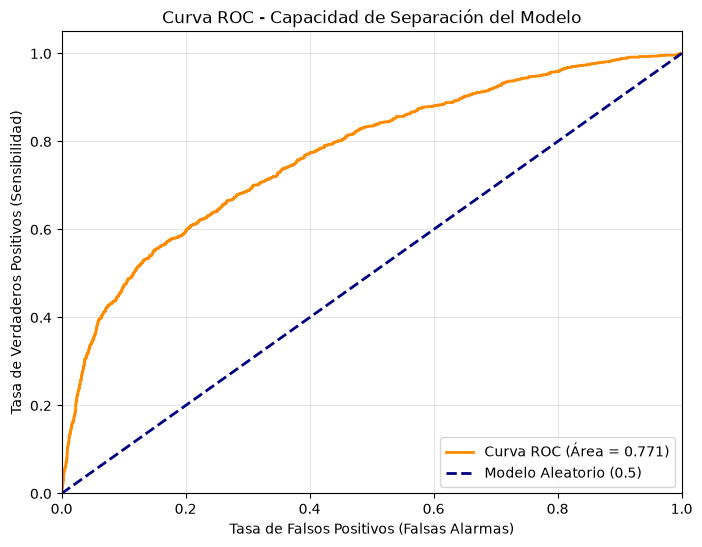

👉 ROC-AUC Score: 0.7707
Interpretación: Un valor cercano a 1.0 indica excelente capacidad de discriminación.


In [8]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Calcular el ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_prob)

# 2. Graficar la curva
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (Área = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Modelo Aleatorio (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Falsas Alarmas)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Capacidad de Separación del Modelo')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"👉 ROC-AUC Score: {roc_auc:.4f}")
print("Interpretación: Un valor cercano a 1.0 indica excelente capacidad de discriminación.")

## Curva Precision-Recall y PR-AUC

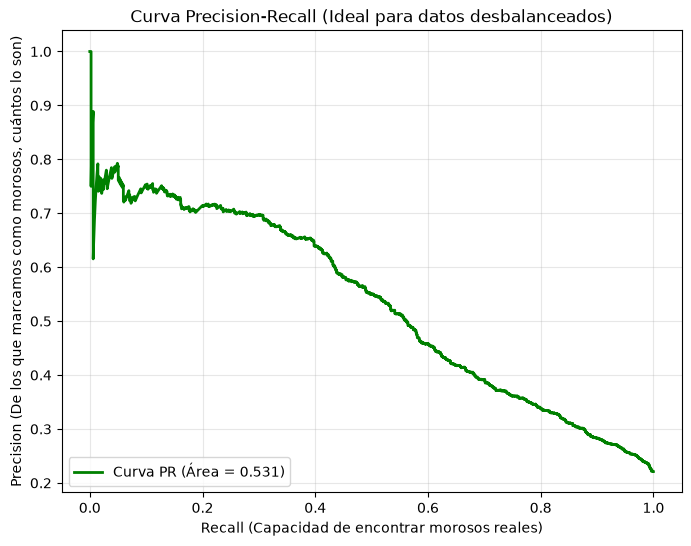

👉 PR-AUC Score (Average Precision): 0.5313
Interpretación: A diferencia del ROC-AUC, esta métrica no se infla por la gran cantidad de clientes buenos (clase 0).


In [9]:
from sklearn.metrics import average_precision_score, precision_recall_curve

# 1. Calcular el PR-AUC (Average Precision)
pr_auc = average_precision_score(y_test, y_pred_prob)
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_prob)

# 2. Graficar la curva
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'Curva PR (Área = {pr_auc:.3f})')
plt.xlabel('Recall (Capacidad de encontrar morosos reales)')
plt.ylabel('Precision (De los que marcamos como morosos, cuántos lo son)')
plt.title('Curva Precision-Recall (Ideal para datos desbalanceados)')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

print(f"👉 PR-AUC Score (Average Precision): {pr_auc:.4f}")
print("Interpretación: A diferencia del ROC-AUC, esta métrica no se infla por la gran cantidad de clientes buenos (clase 0).")